<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/08_Lab_CNN_Ising_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes neuronales convolucionales

In [3]:
import numpy as np
import matplotlib.pylab as plt
import sympy as sp
import scipy as sc
#import tensorflow as tf
#https://setosa.io/ev/image-kernels/

In [4]:
12*1+2*1*1+12*-1+-1+-1

0

# Convolución
![convolucion](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/convolution.png?raw=true)




1. Dada una imagen  :

```
M = array([[10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0]])
```
Apliquemos un filtro
```
filter = array([[ 1,  0, -1],
       [ 1,  0, -1],
       [ 1,  0, -1]])
```

Y construyamos la operacion de convolucion

Results = M * Filter

```
Results = array([[ 0, 30, 30,  0],
       [ 0, 30, 30,  0],
       [ 0, 30, 30,  0],
       [ 0, 30, 30,  0]])
  ```


array([[10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0]])

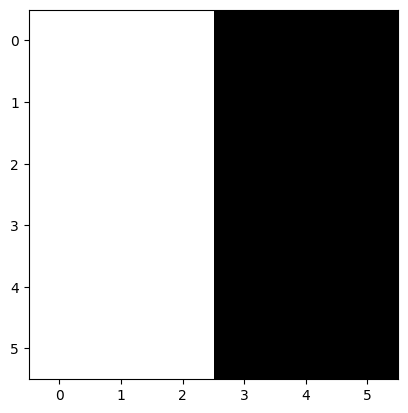

In [5]:
#Construyamos una imagen de negros y blancos
V = np.array([10,10,10,0,0,0])
Img = np.tile(V,6).reshape(6,6)
Img
plt.imshow(Img, cmap="gray")
Img

 Detectemos los bordes con un filtro vertical
```
A = [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
 ```

[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


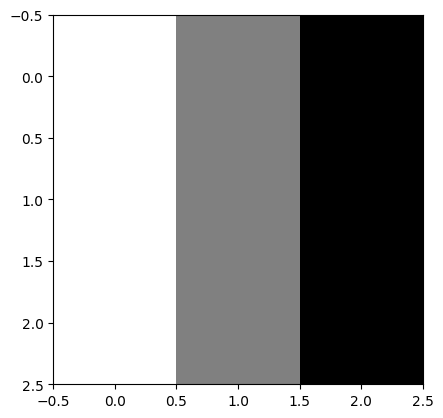

In [6]:
F = np.array([1,0,-1])
filter = np.tile(F,3).reshape(3,3)
print(filter)
plt.imshow(filter, cmap="gray")


La operación de convolución, permite construir una nueva matrix en la que se puede indentificar los bordes.

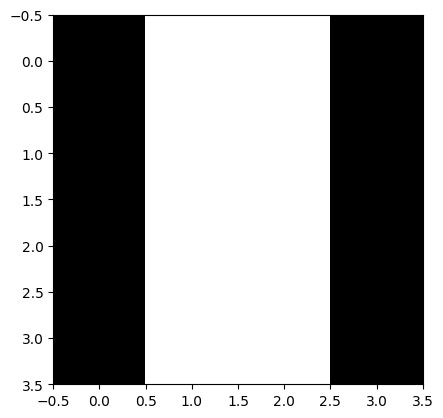

In [7]:
from scipy import signal
#new_img = np.convolve(Img, filter)
new_img = signal.convolve2d(Img, filter,mode="valid")

abs(new_img)
plt.figure()
plt.imshow(abs(new_img), cmap="gray")
plt.show()


In [8]:
new_img

array([[  0, -30, -30,   0],
       [  0, -30, -30,   0],
       [  0, -30, -30,   0],
       [  0, -30, -30,   0]])

In [9]:
# in_img  = tf.constant(Img)
# filter_img  = tf.constant(filter)
# tf.nn.conv2d(in_img, filter_img,padding='VALID')

Apliquemos un filtro horizontal

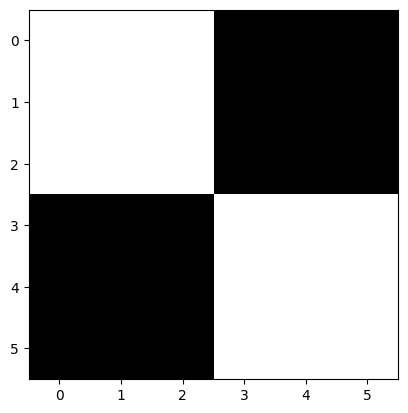

In [10]:
M = np.array([[10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [0, 0, 0,  10,  10,  10],
       [0, 0, 0,  10,  10,  10],
       [0, 0, 0,  10,  10,  10]])

plt.imshow(M, cmap="gray")

In [11]:
sp.Matrix(M)

Matrix([
[10, 10, 10,  0,  0,  0],
[10, 10, 10,  0,  0,  0],
[10, 10, 10,  0,  0,  0],
[ 0,  0,  0, 10, 10, 10],
[ 0,  0,  0, 10, 10, 10],
[ 0,  0,  0, 10, 10, 10]])

Matrix([
[ 1,  1,  1],
[ 0,  0,  0],
[-1, -1, -1]])

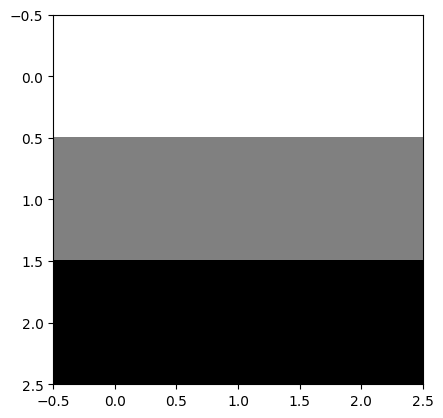

In [12]:
F = np.array([1,0,-1])
filter = np.tile(F,3).reshape(3,3)
filter=filter.T
#print(filter)
plt.imshow(filter, cmap="gray")
sp.Matrix(filter)

[[  0   0   0   0]
 [-30 -10  10  30]
 [-30 -10  10  30]
 [  0   0   0   0]]


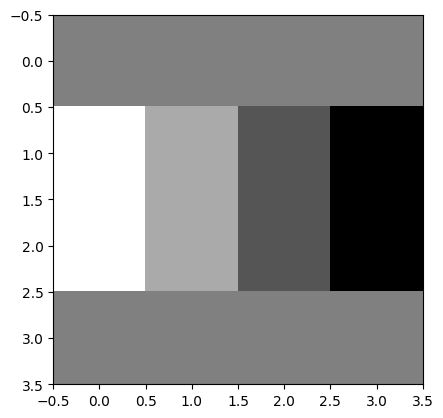

Matrix([
[ 0,  0,   0,   0],
[30, 10, -10, -30],
[30, 10, -10, -30],
[ 0,  0,   0,   0]])

In [13]:
new_img = signal.convolve2d(M,filter,mode="valid")
print(new_img)
plt.figure()
plt.imshow(-new_img, cmap="gray")
plt.show()
sp.Matrix(-new_img)


Existen otro tipo de filtros que pueden ser empleados.

- [Sobel filter](https://en.wikipedia.org/wiki/Sobel_operator)
  ```
  filter = array([[ 1,  0, -1],
       [ 2,  0, -2],
       [ 1,  0, -1]])
```
- Scharr Filter
```
filter = array([[ 3,  0, -3],
       [ 10,  0, -10],
       [ 3,  0, -3]])
```

¿Cómo elegir los parametros del filtro para detectar otro tipo de bordes?
```
filter = array([[ w1,  w2, w3],
     [ w4,  w5, w6],
     [ w7,  w8, w9]])
```

# Padding

El padding permite que la imagen resultante, sea del mismo tamaño que la original. Dada una matrix $n \times n$ asociada a una imagen y aplicada un filtro de rango $f\times f$ la operación después de la convolución es de rango $(n-f+1) \times (n-f+1)$.

Para garantizar que se tenga una imagen con el mismo tamaño de la original se aplica el padding



Para un padding de 1,tenemos entonces la siguientes dimensiones:

###  input = (n)x(n)


![input](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/input.png?raw=true)


### filter = fxf

![filter](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/filter.png?raw=true)



###  Output = (n-f+1)x(n-f+1)


![Output](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/output.png?raw=true)

--------------------------------------------------------------

 ### input con padding = (n+2p)x(n+2p)
![padding](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/padding.png?raw=true)



### filter = fxf

![filter](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/filter.png?raw=true)


###  Output = (n+2p-f+1)x(n+2p-f+1)




## Valid Padding

  - nxn * fxf ---> n-f+1

## Same Padding
The output size is the same that the input size

- n+2pxn+2p * fxf ---> n-f+1+2p x n-f+1+2p


# Stride

Salto entre valores de la imagen para hacer la convolución, en la siguiente imagen se muestra un stride de s=2.

Input : 6x6 = nxn

Filter : 3x3 = fxf

Results = Input * Filter

Results: (6-3)/2--->2x2

$\left[ \frac{n+2*p-f}{s}+1 \right] \times \left[ \frac{n+2*p-f}{s}+1 \right]$

[] operation floor


![stride](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/stride.png?raw=true)




# Convolución sobre todo el volumen:

![volumen](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/rgb_volume.png?raw=true)


## Multiples filtros sobre el volumen:


![multiples filtros](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/rgb_two_filter.png?raw=true)

Input= nxnxnc

Filter= fxfxnc

Output= n-f+1 x  n-f+1  x n'c

nc= numero de canales

n'c= el numero de filtros





REf: https://towardsdatascience.com/beginners-guide-to-understanding-convolutional-neural-networks-ae9ed58bb17d


# Clasificación de fases del modelo de Ising con una red convolucional (Keras)

Este laboratorio es análogo a `07_Lab_NN_IsingV2` (donde construimos un MLP), pero ahora usamos **Keras** — una API de más alto nivel — y una **red convolucional (CNN)** en lugar de un perceptrón multicapa.

Vamos a:

1. Hacer una introducción breve a Keras.
2. Cargar las configuraciones de espines del modelo de Ising (`Datos/ising_dataset.npz`).
3. Construir y entrenar una CNN simple que clasifique cada configuración como fase **ordenada** o **desordenada**.
4. Evaluarla sobre un barrido fino de temperaturas (`Datos/temperatura_critica.npz`) para **estimar la temperatura crítica** $T_c$ a partir de dónde la red cambia de opinión.
5. Bonus: usar la misma red, sin reentrenar, sobre configuraciones de **otro tamaño de red** ($L=20$, `Datos/temperatura_critica20.npz`).

## 0. ¿Qué es Keras?

**Keras** es una API de alto nivel para construir y entrenar redes neuronales. Desde la versión 3, Keras es *multi-backend*: el mismo código (`keras.layers`, `keras.Model`, `.compile()`, `.fit()`, ...) puede ejecutarse sobre **TensorFlow**, **JAX** o **PyTorch** como motor de cómputo. El backend se elige con la variable de entorno `KERAS_BACKEND` **antes** de importar `keras`; el resto del notebook no depende de cuál se use.

Comparado con lo que se hace  "a mano" en PyTorch, Keras encapsula el ciclo de entrenamiento:

| PyTorch (manual)                                              | Keras (equivalente)                    |
|---|---|
| Definir `Dataset` + `DataLoader`                               | Pasar arreglos de NumPy directamente a `.fit()` |
| Escribir el bucle `for epoch ... for batch ...`                | `model.fit(X, y, epochs=..., batch_size=...)` |
| `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` | Ocurre internamente en `.fit()`        |
| Guardar el mejor modelo con un `if val_loss < best_val_loss`   | Callback `keras.callbacks.ModelCheckpoint` |
| `model.eval()` + `torch.no_grad()` + bucle manual              | `model.evaluate(X, y)` / `model.predict(X)` |

Un modelo en Keras se arma apilando **capas** (`keras.layers`) dentro de un `keras.Sequential` (o la API funcional para arquitecturas más complejas), se **compila** indicando optimizador, función de pérdida y métricas, y se **entrena** con `.fit()`.

In [14]:
import os
os.environ.setdefault("KERAS_BACKEND", "jax")  # TensorFlow, JAX o PyTorch: el código de Keras no cambia

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Keras:", keras.__version__)
print("Backend:", keras.backend.backend())

Keras: 3.13.2
Backend: jax


## 1. Datos: configuraciones de espines del modelo de Ising

Reutilizamos el dataset generado en `07_Lab_NN_IsingV2` (ver `07_bDatos_Ising.ipynb` para el detalle de cómo se generó). Cada configuración es una matriz $L\times L$ de espines $\pm 1$, etiquetada según su temperatura respecto a $T_c$:

| | fase **ordenada** (`y = 0`) | fase **desordenada** (`y = 1`) |
|---|---|---|
| temperatura | $T < T_c$ | $T > T_c$ |
| aspecto | un dominio grande domina la red | "ruido", sin dominios |

`ising_dataset.npz` **excluye** una banda alrededor de $T_c$ a propósito, para que las etiquetas sean inequívocas durante el entrenamiento.

In [15]:
!unzip Datos.zip


Archive:  Datos.zip
   creating: Datos/
  inflating: Datos/ising_dataset (1).npz  
  inflating: Datos/ising_dataset.npz  
  inflating: Datos/temperatura_critica.npz  


In [21]:
datos = np.load("Datos/ising_dataset.npz", allow_pickle=False)

X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]
Tc_onsager = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("Temperaturas:", np.unique(T))
print("Realizaciones:", np.unique(realizacion))
print(f"L = {L}   Tc (Onsager) = {Tc_onsager:.4f}")


X: (1600, 16, 16) int8
y: (1600,) int8
Temperaturas: [1.2   1.375 1.55  1.725 1.9   2.6   2.825 3.05  3.275 3.5  ]
Realizaciones: [0 1 2 3]
L = 16   Tc (Onsager) = 2.2692


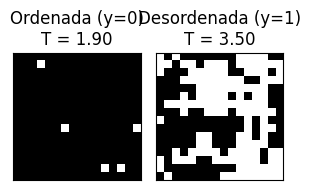

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(3, 3))

idx_ordenada = np.where(y == 0)[0][0]
idx_desordenada = np.where(y == 1)[0][0]

for ax, idx, titulo in zip(
    axes,
    [idx_ordenada, idx_desordenada],
    [f"Ordenada (y=0)\nT = {T[idx_ordenada]:.2f}", f"Desordenada (y=1)\nT = {T[idx_desordenada]:.2f}"],
):
    ax.imshow(X[idx], cmap="gray", vmin=-1, vmax=1)
    ax.set_title(titulo)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## 2. Preparación de los datos para Keras

Igual que en el notebook de PyTorch, usamos el campo `realizacion` (cadena de Monte Carlo independiente) para separar train/val/test, evitando que configuraciones muy correlacionadas de una misma cadena aparezcan en más de un conjunto:

- `realizacion` 0 y 1 → entrenamiento
- `realizacion` 2 → validación
- `realizacion` 3 → test

A diferencia del MLP (que aplanaba cada configuración a un vector de 256 valores), una CNN espera imágenes con forma `(alto, ancho, canales)`. Como tenemos un solo canal (el espín), reformamos cada configuración a `(L, L, 1)`. No hace falta convertir nada a tensores de PyTorch ni armar `DataLoader`s: Keras trabaja directamente con arreglos de NumPy.

In [23]:
mask_train = np.isin(realizacion, [0, 1])
mask_val = realizacion == 2
mask_test = realizacion == 3

def preparar(mask):
    X_ = X[mask].astype("float32").reshape(-1, L, L, 1)
    y_ = y[mask].astype("float32")
    T_ = T[mask]
    return X_, y_, T_

X_train, y_train, T_train = preparar(mask_train)
X_val, y_val, T_val = preparar(mask_val)
X_test, y_test, T_test = preparar(mask_test)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (800, 16, 16, 1) (800,)
Val:   (400, 16, 16, 1) (400,)
Test:  (400, 16, 16, 1) (400,)


## 3. Arquitectura: red convolucional simple

Una CNN es una elección natural para este problema: la fase de una configuración es una propiedad **estadística y global** (¿hay dominios grandes o no?), no depende de *dónde* aparezcan los dominios. Los filtros convolucionales detectan patrones locales (espines alineados con sus vecinos) **sin importar la posición**, exactamente la invariancia que necesitamos.

Arquitectura (deliberadamente simple):

- `Conv2D(8, 3x3) + ReLU` — detecta patrones locales de alineación.
- `MaxPooling2D(2x2)` — reduce la resolución espacial.
- `Conv2D(16, 3x3) + ReLU` — combina patrones locales en patrones un poco más grandes.
- `GlobalAveragePooling2D` — en vez de aplanar (`Flatten`) y usar una capa densa grande, promediamos cada mapa de activación sobre todo el espacio. Esto produce un vector de tamaño fijo **sin importar el tamaño $L\times L$ de la entrada**: la misma red podrá evaluarse más adelante sobre configuraciones de otro tamaño de red, algo que el MLP (con su entrada aplanada de tamaño fijo) no puede hacer.
- `Dense(16) + ReLU` y `Dense(1) + sigmoide` — combinan las características globales en una probabilidad de fase desordenada.

Para permitir tamaños de entrada variables declaramos `Input(shape=(None, None, 1))`.

In [24]:
keras.utils.set_random_seed(42)

model = keras.Sequential(
    [
        keras.Input(shape=(None, None, 1)),
        layers.Conv2D(8, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="ising_cnn",
)

model.summary()

Model: "ising_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, None, None, 8)  │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, None, None, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None, 16) │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compilación y entrenamiento

`compile()` fija el optimizador, la función de pérdida y las métricas a reportar. Como la última capa ya tiene activación sigmoide (produce una probabilidad), usamos `binary_crossentropy` directamente (en PyTorch usamos `BCEWithLogitsLoss` porque la red devolvía *logits*, no probabilidades).

El callback `ModelCheckpoint` guarda automáticamente los pesos con menor `val_loss`, reemplazando el bloque manual `if val_loss < best_val_loss: ...` del notebook de PyTorch.

In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_ising_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
)

historia = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint],
    verbose=2,
)

Epoch 1/20
25/25 - 4s - 178ms/step - accuracy: 0.8487 - loss: 0.5898 - val_accuracy: 1.0000 - val_loss: 0.4615
Epoch 2/20
25/25 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.3420 - val_accuracy: 0.9975 - val_loss: 0.2166
Epoch 3/20
25/25 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.1371 - val_accuracy: 1.0000 - val_loss: 0.0765
Epoch 4/20
25/25 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0512 - val_accuracy: 1.0000 - val_loss: 0.0335
Epoch 5/20
25/25 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0246 - val_accuracy: 1.0000 - val_loss: 0.0195
Epoch 6/20
25/25 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0160 - val_accuracy: 0.9975 - val_loss: 0.0144
Epoch 7/20
25/25 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 8/20
25/25 - 0s - 7ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 9/20
25/25 - 0s - 6ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 10/20
25/25

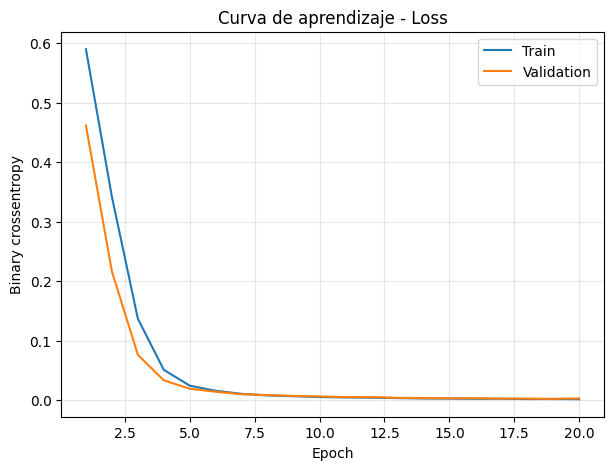

In [26]:
epochs_range = range(1, len(historia.history["loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, historia.history["loss"], label="Train")
plt.plot(epochs_range, historia.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Binary crossentropy")
plt.title("Curva de aprendizaje - Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

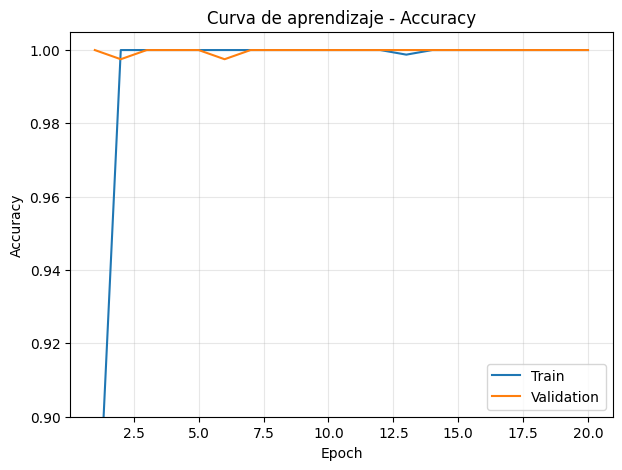

In [27]:
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, historia.history["accuracy"], label="Train")
plt.plot(epochs_range, historia.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0.9, 1.005)
plt.show()

## 5. Evaluación en el conjunto de test

In [28]:
model = keras.models.load_model("best_ising_cnn.keras")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.5f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.00321
Test accuracy: 1.0000


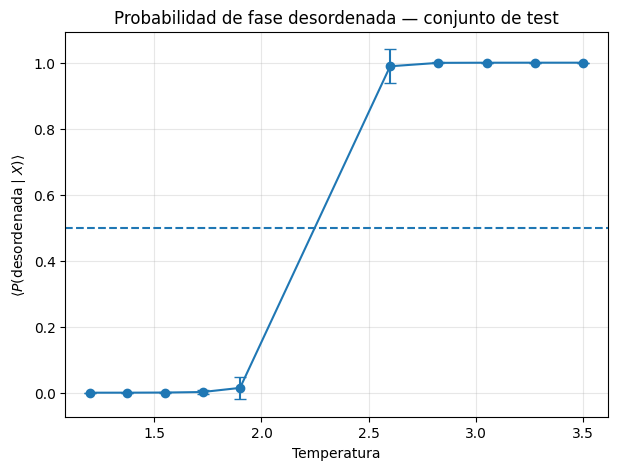

In [29]:
probs_test = model.predict(X_test, verbose=0).ravel()

unique_T_test = np.unique(T_test)
mean_p, std_p = [], []
for temp in unique_T_test:
    mask = T_test == temp
    mean_p.append(probs_test[mask].mean())
    std_p.append(probs_test[mask].std())
mean_p, std_p = np.array(mean_p), np.array(std_p)

plt.figure(figsize=(7, 5))
plt.errorbar(unique_T_test, mean_p, yerr=std_p, fmt="o-", capsize=4)
plt.axhline(0.5, linestyle="--")
plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada} \mid X)\rangle$")
plt.title("Probabilidad de fase desordenada — conjunto de test")
plt.grid(alpha=0.3)
plt.show()

## 6. Barrido cerca de la temperatura crítica

`ising_dataset.npz` deja fuera a propósito una banda alrededor de $T_c$. `temperatura_critica.npz` es el conjunto contrario: un barrido fino que **sí incluye** la zona crítica, con varias realizaciones independientes. Aquí no hay etiqueta de entrenamiento confiable — la idea es que, si la red aprendió a reconocer fases, su probabilidad promedio $\langle P(\mathrm{desordenada}\mid T)\rangle$ pase de 0 a 1 alrededor de la verdadera $T_c$, y podamos **estimar $T_c$ como el punto donde esa curva cruza 0.5**.

In [30]:
datos_tc = np.load("Datos/temperatura_critica.npz", allow_pickle=False)

X_tc = datos_tc["X"].astype("float32").reshape(-1, L, L, 1)
T_tc = datos_tc["T"]
realizacion_tc = datos_tc["realizacion"]

print("X_tc:", X_tc.shape)
print("Temperaturas:", np.unique(T_tc))
print("Realizaciones:", np.unique(realizacion_tc))

X_tc: (6200, 16, 16, 1)
Temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
Realizaciones: [0 1 2 3]


In [31]:
probs_tc = model.predict(X_tc, verbose=0).ravel()
pred_tc = (probs_tc >= 0.5).astype(int)

df = pd.DataFrame({
    "T": T_tc,
    "realizacion": realizacion_tc,
    "probabilidad": probs_tc,
    "prediccion": pred_tc,
})

resumen = (
    df.groupby(["realizacion", "T"])
      .agg(prob_media=("probabilidad", "mean"), prob_std=("probabilidad", "std"), N=("prediccion", "size"))
      .reset_index()
)

resumen.head(10)

,realizacion,T,prob_media,prob_std,N
0,0,1.600,0.000435,0.000341,50
1,0,1.700,0.001301,0.002158,50
2,0,1.800,0.002337,0.004612,50
3,0,1.900,0.004350,0.006657,50
4,0,2.000,0.021877,0.047564,50
5,0,2.050,0.113461,0.192206,50
6,0,2.075,0.077053,0.126211,50
7,0,2.100,0.075800,0.137167,50
8,0,2.125,0.193400,0.302327,50
9,0,2.150,0.241184,0.313026,50


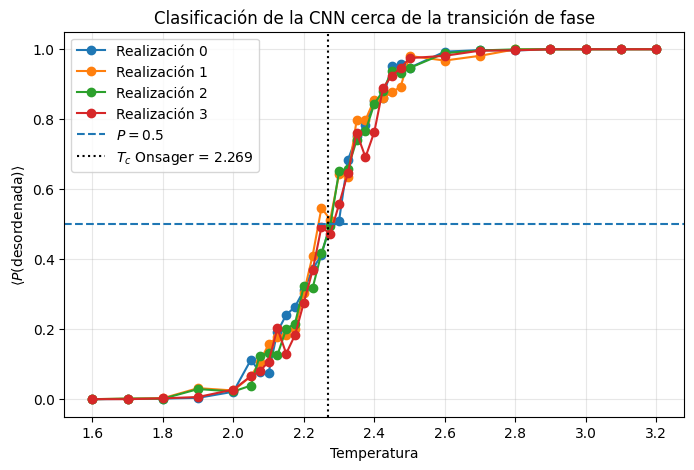

In [32]:
plt.figure(figsize=(8, 5))

for r in np.unique(realizacion_tc):
    datos_r = resumen[resumen["realizacion"] == r]
    plt.plot(datos_r["T"], datos_r["prob_media"], "o-", label=f"Realización {r}")

plt.axhline(0.5, linestyle="--", label=r"$P=0.5$")
plt.axvline(Tc_onsager, linestyle=":", color="k", label=fr"$T_c$ Onsager = {Tc_onsager:.3f}")

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada})\rangle$")
plt.title("Clasificación de la CNN cerca de la transición de fase")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
Tc_estimadas = []

for r in np.unique(realizacion_tc):
    datos_r = resumen[resumen["realizacion"] == r].sort_values("T")
    temps = datos_r["T"].to_numpy()
    probs = datos_r["prob_media"].to_numpy()

    for i in range(len(temps) - 1):
        p1, p2 = probs[i], probs[i + 1]
        if p1 <= 0.5 <= p2:
            T1, T2 = temps[i], temps[i + 1]
            Tc_r = T1 + (0.5 - p1) * (T2 - T1) / (p2 - p1)  # interpolación lineal
            Tc_estimadas.append(Tc_r)
            print(f"Realización {r}: Tc_CNN = {Tc_r:.4f}")
            break

Tc_estimadas = np.array(Tc_estimadas)
Tc_mean = Tc_estimadas.mean()
Tc_std = Tc_estimadas.std(ddof=1)

print()
print(f"Tc_CNN promedio = {Tc_mean:.4f} +/- {Tc_std:.4f}")
print(f"Tc Onsager      = {Tc_onsager:.4f}")

Realización 0: Tc_CNN = 2.2759
Realización 1: Tc_CNN = 2.2414
Realización 2: Tc_CNN = 2.2757
Realización 3: Tc_CNN = 2.2832

Tc_CNN promedio = 2.2691 +/- 0.0188
Tc Onsager      = 2.2692


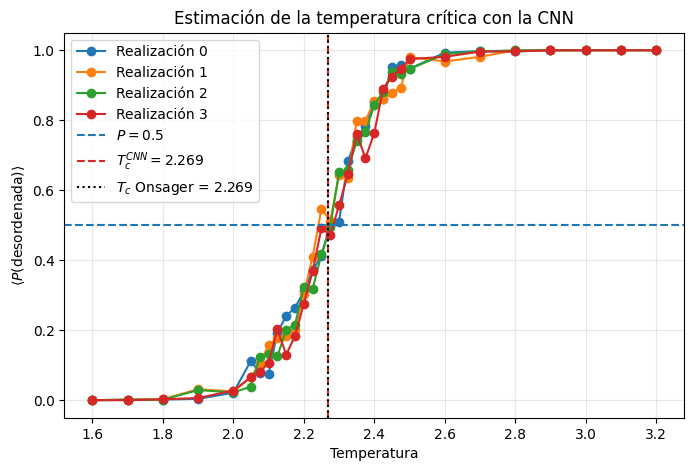

In [34]:
plt.figure(figsize=(8, 5))

for r in np.unique(realizacion_tc):
    datos_r = resumen[resumen["realizacion"] == r]
    plt.plot(datos_r["T"], datos_r["prob_media"], "o-", label=f"Realización {r}")

plt.axhline(0.5, linestyle="--", label=r"$P=0.5$")
plt.axvline(Tc_mean, linestyle="--", color="C3", label=fr"$T_c^{{CNN}} = {Tc_mean:.3f}$")
plt.axvline(Tc_onsager, linestyle=":", color="k", label=fr"$T_c$ Onsager = {Tc_onsager:.3f}")

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada})\rangle$")
plt.title("Estimación de la temperatura crítica con la CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Bonus: generalización a otro tamaño de red ($L=20$)

`GlobalAveragePooling2D` hace que la red no tenga ningún peso atado a un tamaño de entrada específico. Podemos entonces tomar exactamente el mismo modelo, **sin reentrenar**, y evaluarlo sobre `temperatura_critica20.npz` (configuraciones $20\times 20$, con la misma $T_c$ física). Con un MLP de entrada aplanada esto sería imposible sin cambiar la arquitectura.

In [38]:
!unzip Datos.zip


Archive:  Datos.zip
replace Datos/ising_dataset (1).npz? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: Datos/ising_dataset (1).npz  
replace Datos/ising_dataset.npz? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: Datos/ising_dataset.npz  
replace Datos/temperatura_critica.npz? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [40]:
datos_tc20 = np.load("temperatura_critica20.npz", allow_pickle=False)
L20 = int(datos_tc20["L"])

X_tc20 = datos_tc20["X"].astype("float32").reshape(-1, L20, L20, 1)
T_tc20 = datos_tc20["T"]
realizacion_tc20 = datos_tc20["realizacion"]

print(f"L = {L20}   X_tc20: {X_tc20.shape}")

probs_tc20 = model.predict(X_tc20, verbose=0).ravel()

df20 = pd.DataFrame({
    "T": T_tc20,
    "realizacion": realizacion_tc20,
    "probabilidad": probs_tc20,
})

resumen20 = (
    df20.groupby("T")
        .agg(prob_media=("probabilidad", "mean"), prob_std=("probabilidad", "std"))
        .reset_index()
)

L = 20   X_tc20: (6200, 20, 20, 1)


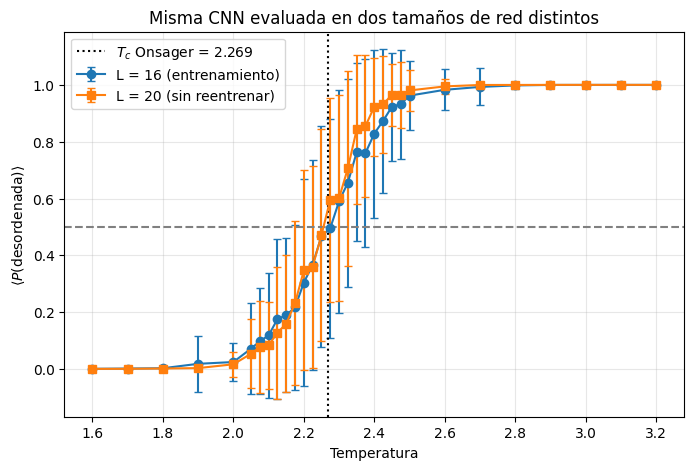

In [41]:
resumen16 = (
    df.groupby("T")
      .agg(prob_media=("probabilidad", "mean"), prob_std=("probabilidad", "std"))
      .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(resumen16["T"], resumen16["prob_media"], yerr=resumen16["prob_std"],
             fmt="o-", capsize=3, label=f"L = {L} (entrenamiento)")
plt.errorbar(resumen20["T"], resumen20["prob_media"], yerr=resumen20["prob_std"],
             fmt="s-", capsize=3, label=f"L = {L20} (sin reentrenar)")

plt.axhline(0.5, linestyle="--", color="gray")
plt.axvline(Tc_onsager, linestyle=":", color="k", label=fr"$T_c$ Onsager = {Tc_onsager:.3f}")

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada})\rangle$")
plt.title("Misma CNN evaluada en dos tamaños de red distintos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Para una red más grande ($L=20$) se espera que la transición se vea **más abrupta** (más cercana al límite termodinámico, donde la transición de fase es discontinua), mientras que en $L=16$ el efecto de tamaño finito la suaviza un poco. Aun así, la misma CNN — sin ver un solo ejemplo de $L=20$ durante el entrenamiento — debería ubicar el cruce cerca de $T_c$.


- Keras permite construir y entrenar la misma clase de clasificador que hicimos con PyTorch en muchas menos líneas: no hay bucle de entrenamiento manual, `DataLoader` ni manejo explícito del dispositivo.
- Una CNN simple (dos capas convolucionales + *global average pooling*) alcanza una exactitud muy alta separando fase ordenada vs. desordenada lejos de $T_c$.
- Evaluando la red sobre el barrido fino de temperaturas, la probabilidad de fase desordenada cruza $0.5$ muy cerca de la $T_c$ de Onsager, sin que la red haya visto nunca esa temperatura durante el entrenamiento.
- Gracias a `GlobalAveragePooling2D`, la arquitectura no depende del tamaño $L\times L$ de la red de espines, lo que permite reutilizar el mismo modelo entrenado sobre configuraciones de otro tamaño — algo que un MLP con entrada aplanada no puede hacer sin cambiar de arquitectura.

# Laboratorio: interpreta la red, no solo confíes en ella

La CNN clasifica fases con exactitud casi perfecta y ubica $T_c$ con buena precisión. Eso no basta: una red puede acertar por razones equivocadas (un atajo espurio en los datos, por ejemplo). Antes de dar el resultado por bueno, ábrela:

- Estudia los kernels de la primera capa convolucional. ¿Qué patrón detecta cada uno? Compáralos con un kernel de "vecinos cercanos" (como el acoplamiento del Hamiltoniano de Ising) y con un kernel de "promedio local" (un detector de magnetización). ¿Se parece alguno a estos kernels físicos, o la red encontró otra cosa?


- Analiza los mapas de activación de esos filtros sobre una configuración ordenada y una desordenada. ¿La diferencia visual que ves coincide con lo que dirías tú, a ojo, si miraras las dos configuraciones sin saber la respuesta?


- Mide qué tan sensible es la red a voltear un solo espín, lejos de $T_c$ y cerca de $T_c$. ¿Dónde es más sensible? ¿Se te ocurre una razón física para eso?

$$S(x) = \frac{1}{L^2}\sum_{i=1}^{L^2} \big|\Delta P_i(x)\big|, \qquad \Delta P_i(x) = P(\text{config. con } s_i \text{ volteado}) - P(x)$$


- Verifica si el logit ($z = Wx+b$) final es, en el fondo, una función de la magnetización. Grafica el logit contra $|m(x)|$, antes y después de entrenar. ¿La red "redescubrió" el parámetro de orden por su cuenta, o el resultado depende de trucos de la arquitectura?